# **D1.2 - Data preprocessing and ML techniques application to imbalanced data**

## **Drive Authentication & Dataset Loading**

In [5]:
import pandas as pd
df = pd.read_csv('../data/ccr.csv')
df.head()

,Rating Agency,Corporation,Rating,Rating Date,CIK,Binary Rating,SIC Code,Sector,Ticker,Current Ratio,...,EBITDA Margin,Pre-Tax Profit Margin,Net Profit Margin,Asset Turnover,ROE - Return On Equity,Return On Tangible Equity,ROA - Return On Assets,ROI - Return On Investment,Operating Cash Flow Per Share,Free Cash Flow Per Share
0,Standard & Poor's Ratings Services,American States Water Co.,A-,2010-07-30,1056903,1,4941.0,Utils,AWR,1.1507,...,28.9834,13.6093,8.3224,0.3173,8.1724,8.1978,2.6385,4.4530,1.9957,-0.1333
1,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,8670,1,7374.0,BusEq,ADP,1.1129,...,23.9379,20.8699,13.5690,0.3324,22.0354,47.2858,4.4944,21.8765,0.2501,0.3132
2,Standard & Poor's Ratings Services,Avnet Inc.,BBB-,2010-11-23,8858,1,5065.0,Shops,AVT,1.9276,...,3.6338,3.0536,2.1418,2.4620,13.6376,16.7991,5.2731,9.6494,-7.6079,-7.3231
3,Standard & Poor's Ratings Services,California Water Service Co.,AA-,2010-06-29,1035201,1,4941.0,Utils,CWT,0.8358,...,27.9377,15.1135,9.0246,0.2946,9.6412,9.7015,2.6583,5.1018,1.7438,-0.8999
4,Standard & Poor's Ratings Services,Cardinal Health Inc.,A,2010-07-14,721371,1,5122.0,Shops,CAH,1.2931,...,1.5847,1.2304,0.6518,4.9276,11.1256,19.4184,2.9364,8.1844,1.9725,2.4174


In [6]:
df.columns

Index(['Rating Agency', 'Corporation', 'Rating', 'Rating Date', 'CIK',
       'Binary Rating', 'SIC Code', 'Sector', 'Ticker', 'Current Ratio',
       'Long-term Debt / Capital', 'Debt/Equity Ratio', 'Gross Margin',
       'Operating Margin', 'EBIT Margin', 'EBITDA Margin',
       'Pre-Tax Profit Margin', 'Net Profit Margin', 'Asset Turnover',
       'ROE - Return On Equity', 'Return On Tangible Equity',
       'ROA - Return On Assets', 'ROI - Return On Investment',
       'Operating Cash Flow Per Share', 'Free Cash Flow Per Share'],
      dtype='str')

## **1. Data Preprocessing**
*   Detail your approach to encoding categorical variables, normalizing, and
standardizing the data.
*   Analysis of the missing data within your dataset and used data imputation strategies (if used).

### 1.1 Data normalization, standardization and encoding

In [7]:
df.info()
df.select_dtypes(include='object').head()

<class 'pandas.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rating Agency                  7805 non-null   str    
 1   Corporation                    7805 non-null   str    
 2   Rating                         7805 non-null   str    
 3   Rating Date                    7805 non-null   str    
 4   CIK                            7805 non-null   int64  
 5   Binary Rating                  7805 non-null   int64  
 6   SIC Code                       7805 non-null   float64
 7   Sector                         7805 non-null   str    
 8   Ticker                         7805 non-null   str    
 9   Current Ratio                  7805 non-null   float64
 10  Long-term Debt / Capital       7805 non-null   float64
 11  Debt/Equity Ratio              7805 non-null   float64
 12  Gross Margin                   7805 non-null   float64
 13 

C:\Users\diego\AppData\Local\Temp\ipykernel_24400\2121662212.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').head()


,Rating Agency,Corporation,Rating,Rating Date,Sector,Ticker
0,Standard & Poor's Ratings Services,American States Water Co.,A-,2010-07-30,Utils,AWR
1,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,BusEq,ADP
2,Standard & Poor's Ratings Services,Avnet Inc.,BBB-,2010-11-23,Shops,AVT
3,Standard & Poor's Ratings Services,California Water Service Co.,AA-,2010-06-29,Utils,CWT
4,Standard & Poor's Ratings Services,Cardinal Health Inc.,A,2010-07-14,Shops,CAH


As there are 3 data types we will first focus on encoding categorical variables, including the dependent variable. In this case, as we are not sure how much information will 'Corporation' provide by encoding it with normal label encoders we will try to compare results with word embeddings. Besides, as the ticker is implicitly included in the corporation we will remove it dimensionality reduction.

In [8]:
df.select_dtypes(include='object').info(verbose=True)
df.select_dtypes(include='object').agg(['dtype', 'nunique']).head().T

<class 'pandas.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Rating Agency  7805 non-null   str  
 1   Corporation    7805 non-null   str  
 2   Rating         7805 non-null   str  
 3   Rating Date    7805 non-null   str  
 4   Sector         7805 non-null   str  
 5   Ticker         7805 non-null   str  
dtypes: str(6)
memory usage: 366.0 KB


C:\Users\diego\AppData\Local\Temp\ipykernel_24400\2178181414.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').info(verbose=True)
C:\Users\diego\AppData\Local\Temp\ipykernel_24400\2178181414.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/m

,dtype,nunique
Rating Agency,str,7
Corporation,str,1377
Rating,str,23
Rating Date,str,1414
Sector,str,12
Ticker,str,678


We load the sentence transformer in order to compute embeddings. We chose the all-MiniLM-L6-v2 BERT based model due to its contextual nature and also, as the sentences that are being converted in embeddings are really short, we selected this reduced version.

In [9]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used: {device}")
model = SentenceTransformer('all-MiniLM-L6-v2').to(device=device)
print(f"Device: {model.device}")

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multiclass-Corporate-Credit-Rating\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dimensionality reduction so we don't have crazy dataframes and to also avoid overfitting. If this idea of the embeddings becomes a problem we will do further feature engineering.

In [10]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used: {device}")
model = SentenceTransformer('all-MiniLM-L6-v2').to(device=device)
print(f"Device: {model.device}")

Device used: cpu


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8627.15it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cpu


Dimensionality reduction so we don't have crazy dataframes and to also avoid overfitting. If this idea of the embeddings becomes a problem we will do further feature engineering.

In [12]:
import umap

embeddings = model.encode(df['Corporation'].unique())

umap_reducer = umap.UMAP(
    n_neighbors=5,
    min_dist=0.1,
    n_components=10,
    metric="cosine",
    random_state=42
)

embeddings_reduced = umap_reducer.fit_transform(embeddings)
print(embeddings_reduced)

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multiclass-Corporate-Credit-Rating\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[[ 9.741966   1.8634237  5.560016  ...  8.90572    4.3910484  1.6467738]
 [11.216569   4.4588     5.4222546 ...  4.8201857  5.351598   6.465053 ]
 [ 9.67274    3.6276853  5.6080227 ...  5.9247212  6.4321227  6.848755 ]
 ...
 [ 8.90417    2.9447324  5.315035  ...  6.150249   7.076586   7.0508285]
 [ 8.358027   3.6407945  5.2523212 ...  5.631318   7.0091515  7.9281616]
 [10.815774   3.406131   5.3732963 ...  9.031148   6.7541285  5.797031 ]]


Create the dataframe with the embeddings.

In [13]:
unique_corporations = df['Corporation'].unique()
corp_embedding = {corp: embedding for corp, embedding in zip(unique_corporations, embeddings_reduced)}

# We will create 10 new columns (e0 to e9) by mapping each corporation in df to its corresponding embedding
embedding_columns_data = df['Corporation'].apply(lambda x: corp_embedding[x])
df_embeddings = pd.DataFrame(embedding_columns_data.tolist(), index=df.index, columns=[f'e{i}' for i in range(10)])

# Now we drop the original columns and concatenate the new embedding columns
df_emb = df.drop(columns=['Ticker', 'Corporation', 'CIK', 'Rating Date']).copy()
df_emb = pd.concat([df_emb, df_embeddings], axis=1)
df_emb.info()

<class 'pandas.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rating Agency                  7805 non-null   str    
 1   Rating                         7805 non-null   str    
 2   Binary Rating                  7805 non-null   int64  
 3   SIC Code                       7805 non-null   float64
 4   Sector                         7805 non-null   str    
 5   Current Ratio                  7805 non-null   float64
 6   Long-term Debt / Capital       7805 non-null   float64
 7   Debt/Equity Ratio              7805 non-null   float64
 8   Gross Margin                   7805 non-null   float64
 9   Operating Margin               7805 non-null   float64
 10  EBIT Margin                    7805 non-null   float64
 11  EBITDA Margin                  7805 non-null   float64
 12  Pre-Tax Profit Margin          7805 non-null   float64
 13 

Here we will convert the categorical features into numerical by different simple encoding methods. The fact that we used an OrdinalEncoder just shows that the Ratings have some kind of positive or negative implicit meaning.

In [28]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

le = LabelEncoder()
oe = OrdinalEncoder(categories=[['D', 'C', 'CC', 'CC+', 'CCC-', 'CCC', 'CCC+', 'B-', 'B', 'B+',
                                 'BB-', 'BB', 'BB+', 'BBB-', 'BBB', 'BBB+', 'A-', 'A', 'A+',
                                 'AA-', 'AA', 'AA+', 'AAA'
                                ]])
df_cat = pd.DataFrame(df.select_dtypes(include='object').copy()).drop(columns=['Ticker', 'Rating Date', 'Corporation'])
df_cat['Rating Agency'] = le.fit_transform(df['Rating Agency'])
df_cat['Corporation'] = le.fit_transform(df['Corporation'])
df_cat['Sector'] = le.fit_transform(df['Sector'])
df_cat['Rating'] = oe.fit_transform(df[['Rating']])

df_emb = pd.concat([df_emb.drop(columns=['Rating Agency', 'Sector', 'Rating']), df_cat], axis=1).drop(columns=['Corporation'])
df_not_emb = pd.concat([df.drop(columns=['Rating Agency', 'Corporation', 'Sector', 'Rating', 'Ticker', 'Rating Date', 'CIK']), df_cat], axis=1)

C:\Users\diego\AppData\Local\Temp\ipykernel_24400\4213576039.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = pd.DataFrame(df.select_dtypes(include='object').copy()).drop(columns=['Ticker', 'Rating Date', 'Corporation'])


Now we will standardize the data meticulously.

Features that will be scaled:
- 'Current Ratio'
- 'Long-term Debt / Capital'
- 'Debt/Equity Ratio'
- 'Gross Margin'
- 'Operating Margin'
- 'EBIT Margin'
- 'EBITDA Margin'
- 'Pre-Tax Profit Margin'
- 'Net Profit Margin'
- 'Asset Turnover'
- 'ROE - Return On Equity'
- 'Return On Tangible Equity'
- 'ROA - Return On Assets'
- 'ROI - Return On Investment',
- 'Operating Cash Flow Per Share'
- 'Free Cash Flow Per Share'
- 'e0', 'e1',... 'e9'

Features that won't change:
- 'SIC Code'
- 'Binary Rating'
- 'Rating Agency'
- 'Rating'
- 'Sector'
- 'Corporation'

This last variables won't be scaled due to their categorical nature.

Although the components of UMAP are already in a manageable range it can be a good idea to scale them in order for the optimizer to converge faster and so as to not give them more relevance than the rest of variables.

In [17]:
from sklearn.preprocessing import StandardScaler

s_cols = ['Current Ratio',
       'Long-term Debt / Capital', 'Debt/Equity Ratio', 'Gross Margin',
       'Operating Margin', 'EBIT Margin', 'EBITDA Margin',
       'Pre-Tax Profit Margin', 'Net Profit Margin', 'Asset Turnover',
       'ROE - Return On Equity', 'Return On Tangible Equity',
       'ROA - Return On Assets', 'ROI - Return On Investment',
       'Operating Cash Flow Per Share', 'Free Cash Flow Per Share']

e_cols = ['e0', 'e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8', 'e9']

se_cols = s_cols + e_cols

scaler = StandardScaler()
df_emb[se_cols] = scaler.fit_transform(df_emb[se_cols])
df_not_emb[s_cols] = scaler.fit_transform(df_not_emb[s_cols])
print(f" Mean {df_emb['e0'].mean()} and std {df_emb['e0'].std()}")

 Mean 5.453108247537476e-16 and std 1.00006406765551


### 1.2 Missing data analysis
In the case of our dataset, we found no missing instances as stated in the first delivery's overall dataset study. However, if we were to find any missing data, we would probably go for predictive ML methods (such as *random forests* or simple regressions) to try to get the most likely value. However, if we were talking about a considerable amount of missing instances, we would likely switch to a less computationally expensive strategy like introducing the *mean/mode/median* even if this might ignores the relations between variables. Although we dont miss anything, we will print the analysis.

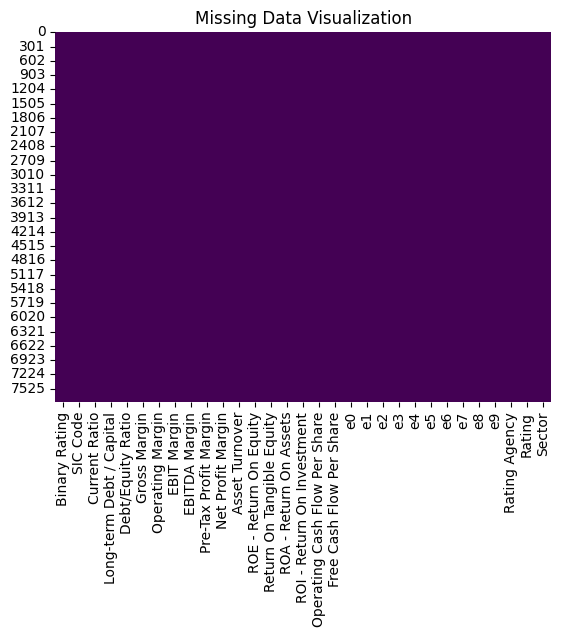

Number of missing instances per variable in our dataset:
Binary Rating                    0
SIC Code                         0
Current Ratio                    0
Long-term Debt / Capital         0
Debt/Equity Ratio                0
Gross Margin                     0
Operating Margin                 0
EBIT Margin                      0
EBITDA Margin                    0
Pre-Tax Profit Margin            0
Net Profit Margin                0
Asset Turnover                   0
ROE - Return On Equity           0
Return On Tangible Equity        0
ROA - Return On Assets           0
ROI - Return On Investment       0
Operating Cash Flow Per Share    0
Free Cash Flow Per Share         0
e0                               0
e1                               0
e2                               0
e3                               0
e4                               0
e5                               0
e6                               0
e7                               0
e8                               

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_emb.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Visualization')
plt.show()

print(f"Number of missing instances per variable in our dataset:\n{df_emb.isnull().sum()}")

## **2. Imbalance Analysis and Mitigation**
*   Analyze the level of class imbalance present in your dataset.
*   Apply and discuss the effectiveness of techniques aimed at mitigating this imbalance
(e.g., SMOTE, undersampling, oversampling).

### 2.1 Class imbalance study
Once again, this analysis was already been made in the first delivery, will cover it here yet. We will focus on the following categorical variables: *Rating Agency*, *Rating* and *Sector*.

In [15]:
cat_cols = df.select_dtypes('object')
cat_cols = cat_cols.drop(columns=['Rating Date', 'Ticker', 'Corporation'])
for c in cat_cols:
  print(f"Class distribution for feature: {c}")
  print(df[c].value_counts(normalize=True)*100)
  print("\n")

Class distribution for feature: Rating Agency
Rating Agency
Egan-Jones Ratings Company            36.207559
Standard & Poor's Ratings Services    36.040999
Moody's Investors Service             20.960922
Fitch Ratings                          6.111467
DBRS                                   0.333120
Japan Credit Rating Agency,Ltd.        0.281871
HR Ratings de Mexico S.A. de C.V.      0.064061
Name: proportion, dtype: float64


Class distribution for feature: Rating
Rating
BBB     11.659193
BBB+    10.839206
A       10.711083
A-       9.250480
BBB-     9.032671
BB+      6.982703
A+       6.124279
BB       5.803972
BB-      5.470852
B+       5.406791
B        3.971813
B-       3.689942
AA-      3.254324
AA       2.370275
CCC+     1.934657
AAA      1.153107
AA+      0.935298
CCC      0.832799
CC       0.230621
C        0.140935
CCC-     0.128123
D        0.064061
CC+      0.012812
Name: proportion, dtype: float64


Class distribution for feature: Sector
Sector
Other    16.028187
Manuf    

C:\Users\diego\AppData\Local\Temp\ipykernel_24400\3986410004.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes('object')


The biggest imbalances we can see are visible in the *Rating Agency* feature, as there are three major agencies that have been studied more in depth than the others that compose the slightest part of the distribution. We could also conclude that the *Rating* variable, the one which we will try to analyze deeper, has also a pretty imbalanced distribution. But far from the *Rating Agency* imbalance. Regarding the sector, there is also a clear imbalance, but not as big as the other two.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, accuracy_score, recall_score, precision_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.pipeline import make_pipeline

def train_test_select(df):
    X = df.drop(columns=['Rating'])
    y = df['Rating']

    # As we had problems to divide the dataset in a stratified manner (stratify=y_filtered) and also the n_neighbours of SMOTE -->
    # --> we have deleted those classes with less than 6 instances
    class_counts = y.value_counts()
    single_member_classes = class_counts[class_counts < 6].index

    if not single_member_classes.empty:
        y_filtered = y[~y.isin(single_member_classes)]
        X_filtered = X.loc[y_filtered.index]
    else:
        X_filtered = X
        y_filtered = y

    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.25, random_state=42, stratify=y_filtered)

    return X_train, X_test, y_train, y_test

In [23]:
def run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=None):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print("Experiment name is " + exp_name)
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("F1: ", f1_score(y_test, y_pred, average='weighted')) # Use weighted average for imbalanced classes
    print(f"The class distribution in the prediction  is: {pd.Series(y_pred).value_counts()}")

lr = LogisticRegression(random_state=42)
rf = RandomForestClassifier(random_state=42)
svc = SVC(random_state=42)
vot_clf = VotingClassifier(estimators=[('lr', lr), ('rf', rf), ('svc', svc)], voting='hard') # Default is hard

In [29]:
pipeline_1 = make_pipeline(RandomOverSampler(random_state=42), vot_clf)
pipeline_2 = make_pipeline(SMOTE(random_state=42), vot_clf)
pipeline_3 = make_pipeline(SMOTEENN(random_state=42), vot_clf)
pipeline_4 = make_pipeline(SMOTETomek(random_state=42), vot_clf)
pipeline_5 = make_pipeline(RandomForestClassifier(random_state=42, class_weight='balanced'))

pipelines_to_run = [
    (pipeline_1, "RandomOverSampler + VotingClassifier"),
    (pipeline_2, "SMOTE + VotingClassifier"),
    (pipeline_3, "SMOTEENN + VotingClassifier"),
    (pipeline_4, "SMOTETomek + VotingClassifier"),
    (pipeline_5, "RandomForestClassifier + class_weight='balanced'") # Changed name to reflect the single model
]

for pipe, name in pipelines_to_run:
    print(f'\n----------------------------------------------\nEVALUATION OF {name} WITHOUT WORD EMBEDDING VARIABLES\n----------------------------------------------\n')
    X_train, X_test, y_train, y_test = train_test_select(df_not_emb)
    run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=name)
    print(f'\n----------------------------------------------\nEVALUATION OF {name} WITHOUT WORD EMBEDDING VARIABLES\n----------------------------------------------\n')
    X_train, X_test, y_train, y_test = train_test_select(df_emb)
    run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=name)


----------------------------------------------
EVALUATION OF RandomOverSampler + VotingClassifier WITHOUT WORD EMBEDDING VARIABLES
----------------------------------------------

Experiment name is RandomOverSampler + VotingClassifier
Accuracy:  0.22153846153846155
F1:  0.2720885105730695
The class distribution in the prediction  is: 1.0     375
2.0     146
10.0    145
12.0    144
16.0    130
4.0     121
15.0    105
14.0    103
5.0     103
7.0      82
9.0      74
13.0     69
18.0     67
17.0     64
11.0     45
6.0      39
19.0     37
8.0      31
22.0     30
21.0     20
20.0     20
Name: count, dtype: int64

----------------------------------------------
EVALUATION OF RandomOverSampler + VotingClassifier WITHOUT WORD EMBEDDING VARIABLES
----------------------------------------------

Experiment name is RandomOverSampler + VotingClassifier
Accuracy:  0.24769230769230768
F1:  0.29768980288199653
The class distribution in the prediction  is: 1.0     245
2.0     228
16.0    204
4.0     197

## **3. Model Comparison and Hyperparameter Tuning**
*    Compare the performance of various models discussed in class, using appropriate metrics (accuracy, recall, precision, F1 score, MCC, etc.).
*   Explain the hyperparameter tuning, describing how you searched for and selected the optimal parameters for each model.
*   Use optuna for hyperparameter tuning using a pruner or a heuristic.
*   Cover at least four of the different ensemble learning methods we have seen in class.



### Optuna for hyperparameter tuning:
Compared to other frameworks such as Scikit-Learn, Optuna offers more advanced tools and more customization for optimizing processes. However, the main advantage this framework offers is the possibility of directly pruning those runs that do not look great, saving us so much time in the training process. The heuristics that decide whether to stop a training process are based on the intermediate training values such as poor evaluation metrics or bad performance on the training set.

In [19]:
import optuna
from sklearn.model_selection import cross_val_score
import sklearn.ensemble
import sklearn.linear_model
import sklearn.svm
from optuna.storages import JournalStorage
from optuna.storages.journal import JournalFileBackend
import warnings
from sklearn.exceptions import ConvergenceWarning

storage_url = "sqlite:///optuna_study.db"

classifiers = ["LogisticRegression", "RandomForestClassifier", "SVC"]

def objective(trial):
  classifier = trial.suggest_categorical("classifier", classifiers)

  if classifier == "LogisticRegression":
    lr_c = trial.suggest_float("lr_c", 1e-4, 1e4, log=True)
    lr_solver = trial.suggest_categorical("lr_solver", ['lbfgs', 'saga'])
    lr_penalty = trial.suggest_categorical("lr_penalty", ['l1', 'l2'])
    if lr_solver == 'lbfgs' and lr_penalty == 'l1':
        raise optuna.TrialPruned()

    lr_max_iter = trial.suggest_int("lr_max_iter", 100, 1000, step=100)

    obj_classifier = sklearn.linear_model.LogisticRegression(
        C=lr_c, solver=lr_solver, penalty=lr_penalty, max_iter=lr_max_iter, random_state=42)

  elif classifier == "RandomForestClassifier":
    rf_estimators = trial.suggest_int("rf_estimators", 50, 200, step=50)
    rf_max_features = trial.suggest_categorical("rf_max_features", ['sqrt', 'log2'])
    rf_max_depth = trial.suggest_int("rf_max_depth", 10, 50, step=10)
    rf_min_samples_split = trial.suggest_int("rf_min_samples_split", 2, 10, step=1)
    rf_min_samples_leaf = trial.suggest_int("rf_min_samples_leaf", 1, 4, step=1)
    rf_criterion = trial.suggest_categorical("rf_criterion", ['gini', 'entropy'])

    obj_classifier = sklearn.ensemble.RandomForestClassifier(
        n_estimators=rf_estimators, max_features=rf_max_features, max_depth=rf_max_depth,
        min_samples_split = rf_min_samples_split, min_samples_leaf = rf_min_samples_leaf,
        criterion = rf_criterion, random_state=42)

  elif classifier == "SVC":
    svc_c = trial.suggest_float("svc_c", 1e-2, 1e2, log=True)
    svc_kernel = trial.suggest_categorical("svc_kernel", ['linear', 'rbf', 'poly', 'sigmoid'])
    svc_gamma = trial.suggest_categorical("svc_gamma", ['scale', 'auto'])

    obj_classifier = sklearn.svm.SVC(C=svc_c, kernel=svc_kernel, gamma=svc_gamma)

  with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=UserWarning)

    score = cross_val_score(obj_classifier, X_train, y_train, n_jobs=1, cv=3)
    accuracy = score.mean()

  return accuracy

When it comes to the hyperparameters we will try for our project, we have wanted to go further and try many more apart from the standard ones we have been able to find in the notebook. Let's list them down and describe what they are and the values used for each!



*   Logistic Regression:


    1. ``C``: is the inverse of the regularization strength (which must be a non-negative positive float). A regularization hyperparameter, whose smaller values indicate smaller penalization. We will use values ranging from 1e-4 up to 1e4.
    2. ``solver``: refers to the optimization algorithm used. We have not chosen all that are offered, just *lbfgs* (works great for the majority of problems), *saga* (fast algorithm for large dataset as ours).
    3. ``penalty``: specifies the norm of the penaly. *l1* and *l2* being the L1/L2 penalties applied. Both of them being regularization methods already seen in class.
    (When it comes to using the *lbfgs*, there was no other compatible option than using the *l1* regularization.)


*   Random Forest:
*   Support Vector Classifier:



Running time! We will use the studied pruner ``MedianPruner`` which compares the intermediate result of a run to the best trial's intermediate result to decide whether to prune or not. We will also parallelize it as it would take so much time otherwise. However, as there are multiple processes running at once and not all of them are of the same length, we may see unordered trial numbers. Meaning that *trial i+1* may have finished earlier than *trial i*. We have also added the functionality to ignore the warnings so the experiment verbose is not a mess.

In [ ]:
study = optuna.create_study(
    direction="maximize",  
    storage=storage_url, # we will store the results in a small db
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5) # pruner config
)

study.optimize(objective, n_trials=30, n_jobs=3) # threads parallely

[I 2026-03-21 10:26:33,585] A new study created in RDB with name: classifier_optimization
[I 2026-03-21 10:26:37,673] Trial 1 finished with value: 0.5292530771697438 and parameters: {'classifier': 'RandomForestClassifier', 'rf_estimators': 100, 'rf_max_features': 'sqrt', 'rf_max_depth': 20, 'rf_min_samples_split': 10, 'rf_min_samples_leaf': 4, 'rf_criterion': 'gini'}. Best is trial 1 with value: 0.5292530771697438.
[I 2026-03-21 10:26:40,583] Trial 0 finished with value: 0.5300532800532801 and parameters: {'classifier': 'RandomForestClassifier', 'rf_estimators': 150, 'rf_max_features': 'sqrt', 'rf_max_depth': 40, 'rf_min_samples_split': 3, 'rf_min_samples_leaf': 4, 'rf_criterion': 'gini'}. Best is trial 0 with value: 0.5300532800532801.
[I 2026-03-21 10:26:48,101] Trial 3 finished with value: 0.5298929465596133 and parameters: {'classifier': 'RandomForestClassifier', 'rf_estimators': 200, 'rf_max_features': 'sqrt', 'rf_max_depth': 20, 'rf_min_samples_split': 5, 'rf_min_samples_leaf': 4

Let's now run the model with the best hyperparameters obtained in the optuna study.

In [ ]:
print("Best trial:")
trial = study_corporate_optuna.best_trial

print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"\n{key}: {value}")


Best trial:


NameError: name 'study_corporate_optuna' is not defined

## **4. Results Discussion**
*    Present the results obtained from your models, focusing on the metrics chosen to evaluate their performance. Use tables to compare them.
*   Highlight any interesting findings or patterns observed during your analysis.


## **5. Lessons Learned**


*   Identify key challenges you faced during the project and how you overcame them.
*   Share any insights gained from working with an imbalanced dataset and the impact of various preprocessing and modeling techniques on your results.

